## Libraries

In [1]:
import pandas as pd
import geopandas as gpd
import os
import json
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import math
import numpy as np

## Linking Functions notebook

In [2]:
# Adding path to system
import sys
sys.path.append(r"C:\\Users\\eliya\\Documents\\עבודה\\עוזר מחקר\\4. פרויקטים\\1. quality measures\\1. Feature Completeness")

In [3]:
# Importing relevant functions
import importlib
from functions import get_len, get_count, get_area, get_add_from_cum, semi_norm_mix_transform, wrap_api_query

### Updating quality function

In [142]:
# Generate a mixed transformation ratio of cumulative size divided by cumulative counts
def semi_norm_mix_transform(count_gdf, size_gdf, alpha=0.3, time_thresh=2, return_full=False):
    '''
    Receives two GeoDataFrames (assumes identical timestamps and geometry):
    1) A cumulative count of added features by timestamps
    2) A cumulative length of all features by timestamps

    The function converts timestamp to actual datetime format, transforms the values to a mixed normalized percentage of added value (length / area) per each added unit.
    After that, the function applies the following statistical test:
    
    `If all cumulative change percentage is below some alpha (default: 30%) for a stable time period (default: 2 years), the data is considered saturated.`
    
    For saturated data, the function then computes the saturation point (1st month in stable period) and calculates cumulative percentage up to that point.

    In all cases, the output is a DataFrame:
    * If not saturated --> the merged DataFrame, with updated timstamps and calculations.
    * If saturated --> can either return only values up to the saturation point + maximum value (default) or return the entire data with reference to the saturation point.
    '''
    # Fix timestamp
    count_gdf['timestamp'] = pd.to_datetime(count_gdf['timestamp'])
    size_gdf['timestamp'] = pd.to_datetime(size_gdf['timestamp'])

    # Sort both DataFrames by timestamp and reset index for proper alignment
    count_gdf = count_gdf.sort_values('timestamp').reset_index(drop=True)
    size_gdf = size_gdf.sort_values('timestamp').reset_index(drop=True)

    # Merge Dataframes
    gdf = count_gdf.copy().rename(columns={'value' : 'count'}) # Copy DF and rename count column
    gdf['size'] = size_gdf['value'] # Append size column
    
    # Transform values
    gdf['cumulative_percentage'] = gdf['size'] / gdf['count']
    gdf['cumulative_percentage'] = gdf['cumulative_percentage'].fillna(0) # Deal with periods without addition
    gdf['normalized_cum_per'] = gdf['cumulative_percentage'] / gdf['cumulative_percentage'].max()

    # Apply completeness test for level alpha
    gdf['test'] = (gdf['normalized_cum_per'] < alpha) # Boolean term for each date in data

    ## Iterate backwards in data to find stability period
    i = -1 # Running index (from end)
    test = gdf['test'].iat[i] # Running boolean test answer (from end)
    while test:
        try: # Update index
            i -= 1
            test = gdf['test'].iat[i]
        
        except IndexError: # Break loop if at first index
            break
    
    if i == -1:
        # Deal with last value percentage being greater than alpha (i.e. no stable period)
        print('Data incomplete')
        return gdf
    
    stable = gdf.iloc[i+1:].copy() # Extract stable period

    ## If stable period shorter than given time threshold --> data is incomplete
    if (stable['timestamp'].max() - stable['timestamp'].min()) < pd.Timedelta(days=time_thresh*365):
        print('Data incomplete')
        return gdf

    ## For complete data
    else:
        # Extract saturated value
        saturation_point = stable.iloc[0]

        # Calculate saturation levels
        gdf['percentage_until_saturation'] = gdf['count'] / saturation_point['count']
        
         # Extract emprical maximal value
        real_max = gdf.iloc[-1]
      
        # Extract 80% saturation timestamp
        saturated_time = gdf[gdf['percentage_until_saturation'] >= 0.8]['timestamp'].iloc[0]
        print(f'Polygon 80% saturated at {saturated_time}')

        ### Return entire gdf if requested
        if return_full:
            return gdf
        
        ### Return compact gdf (default)
        else:
            # Filter data until saturation
            saturated = gdf.iloc[:i+1].copy()
        
            # Concatenate empirical maximal value
            saturated = pd.concat([saturated,
                                   pd.DataFrame([real_max])],
                                   ignore_index=True)       
            return saturated

## Events check

In [5]:
counts_rds = pd.read_csv(r"C:\Users\eliya\Documents\עבודה\עוזר מחקר\4. פרויקטים\1. quality measures\1. Feature Completeness\1) Data\2) Events export\road_counts.csv")
lengths = pd.read_csv(r"C:\Users\eliya\Documents\עבודה\עוזר מחקר\4. פרויקטים\1. quality measures\1. Feature Completeness\1) Data\2) Events export\road_lengths.csv")
counts_bld = pd.read_csv(r"C:\Users\eliya\Documents\עבודה\עוזר מחקר\4. פרויקטים\1. quality measures\1. Feature Completeness\1) Data\2) Events export\building_counts.csv")
areas = pd.read_csv(r"C:\Users\eliya\Documents\עבודה\עוזר מחקר\4. פרויקטים\1. quality measures\1. Feature Completeness\1) Data\2) Events export\building_areas.csv")

#### Testing using new function

In [6]:
# Test for lists for plots
roads_test = []
bldgs_test = []

for idx, count_group in counts_rds.groupby('idx'):
    len_group = lengths[lengths['idx'] == idx].copy() # grouping length dataframe entries
    t1 = semi_norm_mix_transform(count_group, len_group, alpha=0.1)
    t1.loc[:, 'idx'] = idx  # preserve original index
    roads_test.append(t1)

for idx, count_group in counts_bld.groupby('idx'):
    area_group = areas[areas['idx'] == idx].copy() # grouping area dataframe entries
    t2 = semi_norm_mix_transform(count_group, area_group, alpha=0.1)
    t2.loc[:, 'idx'] = idx # preserve original index
    bldgs_test.append(t2)

Data incomplete: stable addition larger than threshold
Data incomplete: stable period shorter than threshold
Data incomplete: stable addition larger than threshold
Data incomplete: stable addition larger than threshold
Data incomplete: stable addition larger than threshold
Date complete:
Polygon 80% saturated at 2019-04-01 00:00:00+00:00
Data incomplete: stable addition larger than threshold
Data incomplete: stable addition larger than threshold
Data incomplete: stable addition larger than threshold
Data incomplete: no stable period
Data incomplete: no stable period
Data incomplete: stable addition larger than threshold
Data incomplete: stable addition larger than threshold
Data incomplete: stable addition larger than threshold
Data incomplete: stable addition larger than threshold
Data incomplete: stable addition larger than threshold
Data incomplete: stable addition larger than threshold
Data incomplete: stable addition larger than threshold
Data incomplete: no stable period
Data inc

### Plots

In [144]:
# Test for lists for plots
roads_test_samp = []
bldgs_test_samp = []

for idx, count_group in counts_rds.groupby('idx'):
    if idx not in range(6):
        break
    len_group = lengths[lengths['idx'] == idx].copy() # grouping length dataframe entries
    t1 = semi_norm_mix_transform(count_group, len_group, alpha=0.1, return_full=True)
    t1.loc[:, 'idx'] = idx  # preserve original index
    roads_test_samp.append(t1)

for idx, count_group in counts_bld.groupby('idx'):
    if idx not in range(6):
        break
    area_group = areas[areas['idx'] == idx].copy() # grouping area dataframe entries
    t2 = semi_norm_mix_transform(count_group, area_group, alpha=0.1, return_full=True)
    t2.loc[:, 'idx'] = idx # preserve original index
    bldgs_test_samp.append(t2)

Polygon 80% saturated at 2012-03-01 00:00:00+00:00
Data incomplete
Polygon 80% saturated at 2015-09-01 00:00:00+00:00
Polygon 80% saturated at 2014-01-01 00:00:00+00:00
Polygon 80% saturated at 2015-03-01 00:00:00+00:00
Polygon 80% saturated at 2019-04-01 00:00:00+00:00
Polygon 80% saturated at 2012-03-01 00:00:00+00:00
Data incomplete
Data incomplete
Polygon 80% saturated at 2017-04-01 00:00:00+00:00
Data incomplete
Data incomplete


#### Road completeness

##### Normal scale:

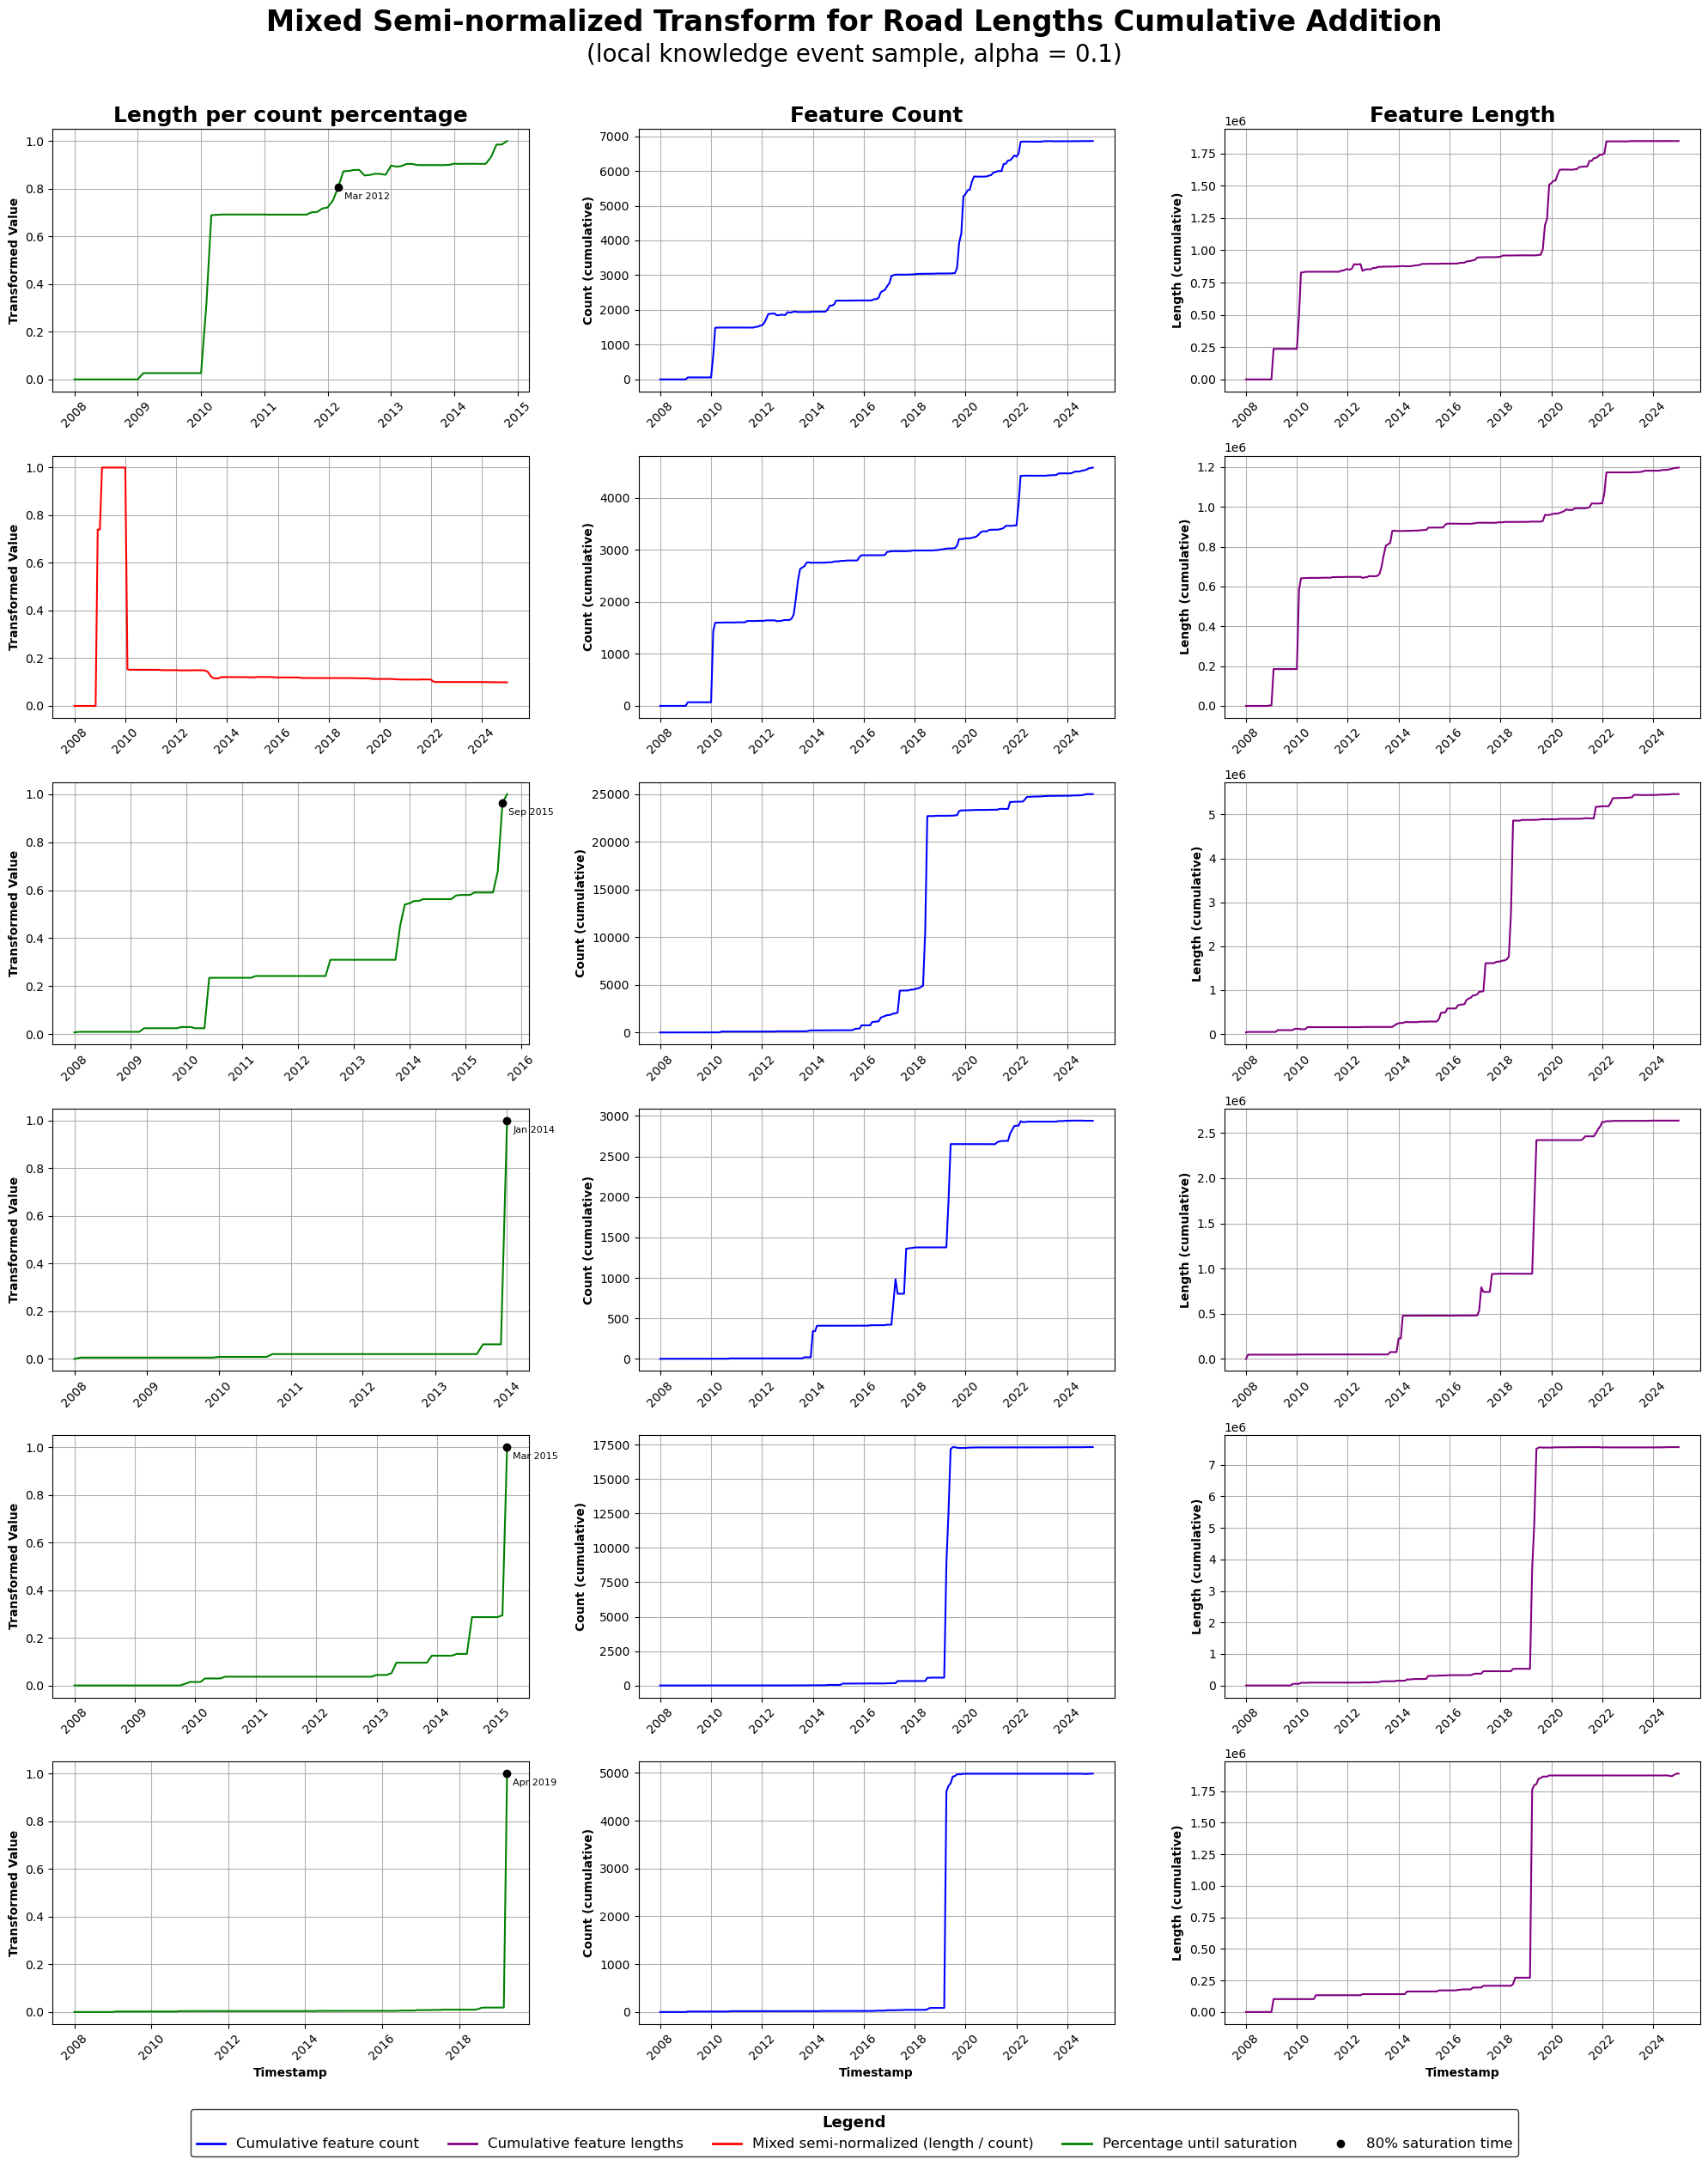

In [145]:
# Defining dataframes and subplot titles
fig, axes = plt.subplots(nrows=6, ncols=3, figsize=(20, 24))
column_titles = ['Length per count percentage', 'Feature Count', 'Feature Length'] # Column titles

for i, df in enumerate(roads_test_samp):
    for j in range(3):
        ax = axes[i, j]
        # Plot 1: saturation percentage
        if j == 0:
            # Saturated values:
            if 'percentage_until_saturation' in df.columns:
                sat = (df['percentage_until_saturation'] >= 0.99).idxmax()
                df_plt = df.iloc[:sat + 1]
                ax.plot(df_plt['timestamp'], df_plt['percentage_until_saturation'], linestyle='-', color='g', label='Percentage until saturation')

                # Adding saturation point
                saturation = df[df['percentage_until_saturation'] >= 0.8].iloc[0]
                ax.scatter(saturation['timestamp'], saturation['percentage_until_saturation'], color='black', zorder=5, label='80% saturation')
                ax.annotate(pd.to_datetime(saturation['timestamp']).strftime('%b %Y'), xy=(saturation['timestamp'], saturation['percentage_until_saturation']),
                            xytext=(5, -10), textcoords='offset points', fontsize=8, color='black')

            # Un-saturated values:      
            else:
                ax.plot(df['timestamp'], df['normalized_cum_per'], linestyle='-', color='r', label='Mixed semi-normalized (length / count)')
            ax.set_ylabel('Transformed Value', weight='bold')
            if i == 5:
                # Only bottom of each column
                ax.set_xlabel('Timestamp', weight='bold')
            ax.tick_params(axis='x', rotation=45)
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
            ax.grid(True)

        # Plot 2: feature counts
        elif j == 1:
            ax.plot(df['timestamp'], df['count'], linestyle='-', color='b', label='Cumulative feature count')
            ax.set_ylabel('Count (cumulative)', weight='bold')
            if i == 5:
                # Only bottom of each column
                ax.set_xlabel('Timestamp', weight='bold')
            ax.tick_params(axis='x', rotation=45)
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
            ax.grid(True)

        # Plot 3: feature lengths
        elif j == 2:
            ax.plot(df['timestamp'], df['size'], linestyle='-', color='purple', label='Cumulative feature lengths')
            ax.set_ylabel('Length (cumulative)', weight='bold')
            if i == 5:
                # Only bottom of each column
                ax.set_xlabel('Timestamp', weight='bold')
            ax.tick_params(axis='x', rotation=45)
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
            ax.grid(True)
        
        # Setting titles per each column
        if i == 0:
            axes[0, j].set_title(column_titles[j], fontsize=18, fontweight = 'bold')

# Setting legend
legend_elements = [
    Line2D([0], [0], color='b', lw=2, label='Cumulative feature count'),
    Line2D([0], [0], color='purple', lw=2, label='Cumulative feature lengths'), 
    Line2D([0], [0], color='r', lw=2, label='Mixed semi-normalized (length / count)'),
    Line2D([0], [0], color='g', lw=2, label='Percentage until saturation'),
    Line2D([0], [0], marker='o', color='black', linestyle='', label='80% saturation time')
]

legend = fig.legend(
    handles=legend_elements,
    loc='upper center',
    ncol=5,
    bbox_to_anchor=(0.5, -0.005),
    fontsize=12,
    frameon=True,
    title='Legend',
    title_fontsize=13
)
#legend = legend_ax.legend(handles=legend_elements, loc='center', frameon=True, title='Legend')
legend.get_frame().set_edgecolor('black')
legend.get_title().set_fontweight('bold')

# Title
fig.text(0.5, 1, 'Mixed Semi-normalized Transform for Road Lengths Cumulative Addition',
         fontsize=24, fontweight='bold', ha='center')
fig.text(0.5, 0.985, '(local knowledge event sample, alpha = 0.1)',
         fontsize=20, fontweight='normal', ha='center')

# Showing plots
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

##### Log scaled:

c:\Users\eliya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\eliya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\eliya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\eliya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


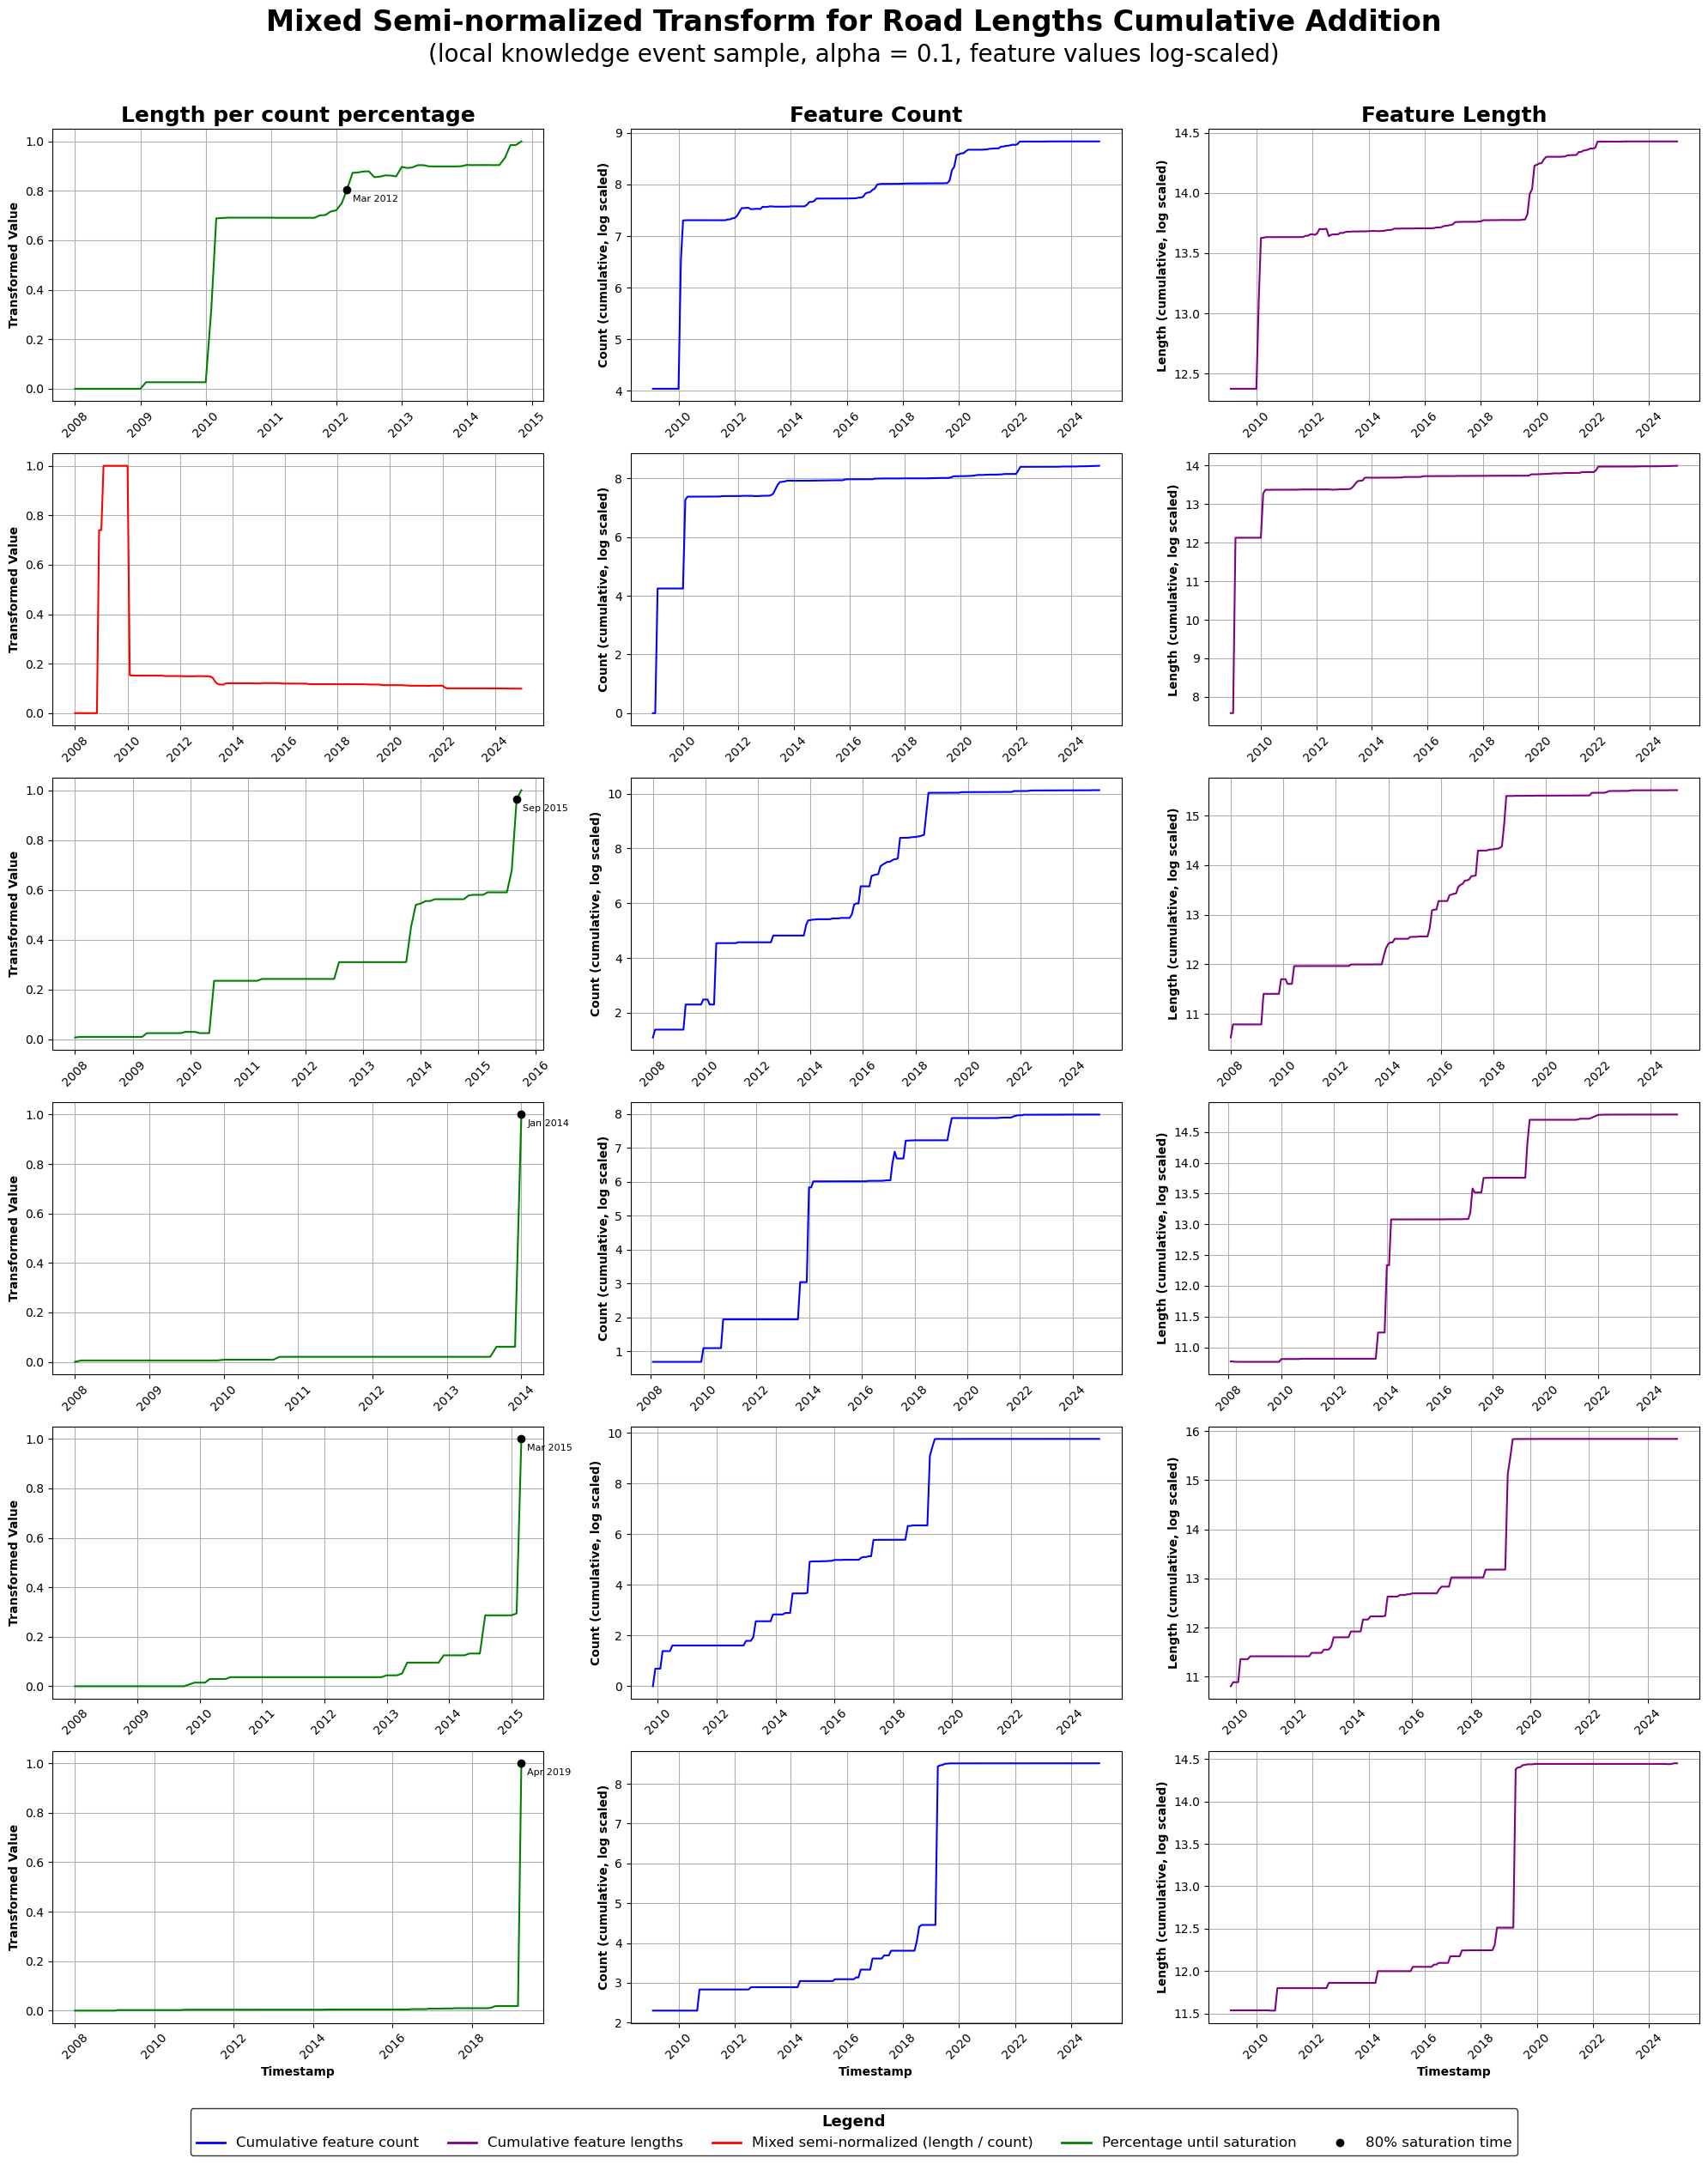

In [146]:
# Defining dataframes and subplot titles
fig, axes = plt.subplots(nrows=6, ncols=3, figsize=(20, 24))
column_titles = ['Length per count percentage', 'Feature Count', 'Feature Length'] # Column titles

for i, df in enumerate(roads_test_samp):
    for j in range(3):
        ax = axes[i, j]
        # Plot 1: saturation percentage
        if j == 0:
            # Saturated values:
            if 'percentage_until_saturation' in df.columns:
                sat = (df['percentage_until_saturation'] >= 0.99).idxmax()
                df_plt = df.iloc[:sat + 1]
                ax.plot(df_plt['timestamp'], df_plt['percentage_until_saturation'], linestyle='-', color='g', label='Percentage until saturation')

                # Adding saturation point
                saturation = df[df['percentage_until_saturation'] >= 0.8].iloc[0]
                ax.scatter(saturation['timestamp'], saturation['percentage_until_saturation'], color='black', zorder=5, label='80% saturation')
                ax.annotate(pd.to_datetime(saturation['timestamp']).strftime('%b %Y'), xy=(saturation['timestamp'], saturation['percentage_until_saturation']),
                            xytext=(5, -10), textcoords='offset points', fontsize=8, color='black')

            # Un-saturated values:      
            else:
                ax.plot(df['timestamp'], df['normalized_cum_per'], linestyle='-', color='r', label='Mixed semi-normalized (length / count)')
            ax.set_ylabel('Transformed Value', weight='bold')
            if i == 5:
                # Only bottom of each column
                ax.set_xlabel('Timestamp', weight='bold')
            ax.tick_params(axis='x', rotation=45)
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
            ax.grid(True)

        # Plot 2: feature counts
        elif j == 1:
            ax.plot(df['timestamp'], np.log(df['count']), linestyle='-', color='b', label='Cumulative feature count')
            ax.set_ylabel('Count (cumulative, log scaled)', weight='bold')
            if i == 5:
                # Only bottom of each column
                ax.set_xlabel('Timestamp', weight='bold')
            ax.tick_params(axis='x', rotation=45)
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
            ax.grid(True)

        # Plot 3: feature lengths
        elif j == 2:
            ax.plot(df['timestamp'], np.log(df['size']), linestyle='-', color='purple', label='Cumulative feature lengths')
            ax.set_ylabel('Length (cumulative, log scaled)', weight='bold')
            if i == 5:
                # Only bottom of each column
                ax.set_xlabel('Timestamp', weight='bold')
            ax.tick_params(axis='x', rotation=45)
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
            ax.grid(True)
        
        # Setting titles per each column
        if i == 0:
            axes[0, j].set_title(column_titles[j], fontsize=18, fontweight = 'bold')

# Setting legend
legend_elements = [
    Line2D([0], [0], color='b', lw=2, label='Cumulative feature count'),
    Line2D([0], [0], color='purple', lw=2, label='Cumulative feature lengths'), 
    Line2D([0], [0], color='r', lw=2, label='Mixed semi-normalized (length / count)'),
    Line2D([0], [0], color='g', lw=2, label='Percentage until saturation'),
    Line2D([0], [0], marker='o', color='black', linestyle='', label='80% saturation time')
]

legend = fig.legend(
    handles=legend_elements,
    loc='upper center',
    ncol=5,
    bbox_to_anchor=(0.5, -0.005),
    fontsize=12,
    frameon=True,
    title='Legend',
    title_fontsize=13
)
#legend = legend_ax.legend(handles=legend_elements, loc='center', frameon=True, title='Legend')
legend.get_frame().set_edgecolor('black')
legend.get_title().set_fontweight('bold')

# Title
fig.text(0.5, 1, 'Mixed Semi-normalized Transform for Road Lengths Cumulative Addition',
         fontsize=24, fontweight='bold', ha='center')
fig.text(0.5, 0.985, '(local knowledge event sample, alpha = 0.1, feature values log-scaled)',
         fontsize=20, fontweight='normal', ha='center')

# Showing plots
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

#### Building completeness

##### Normal scale:

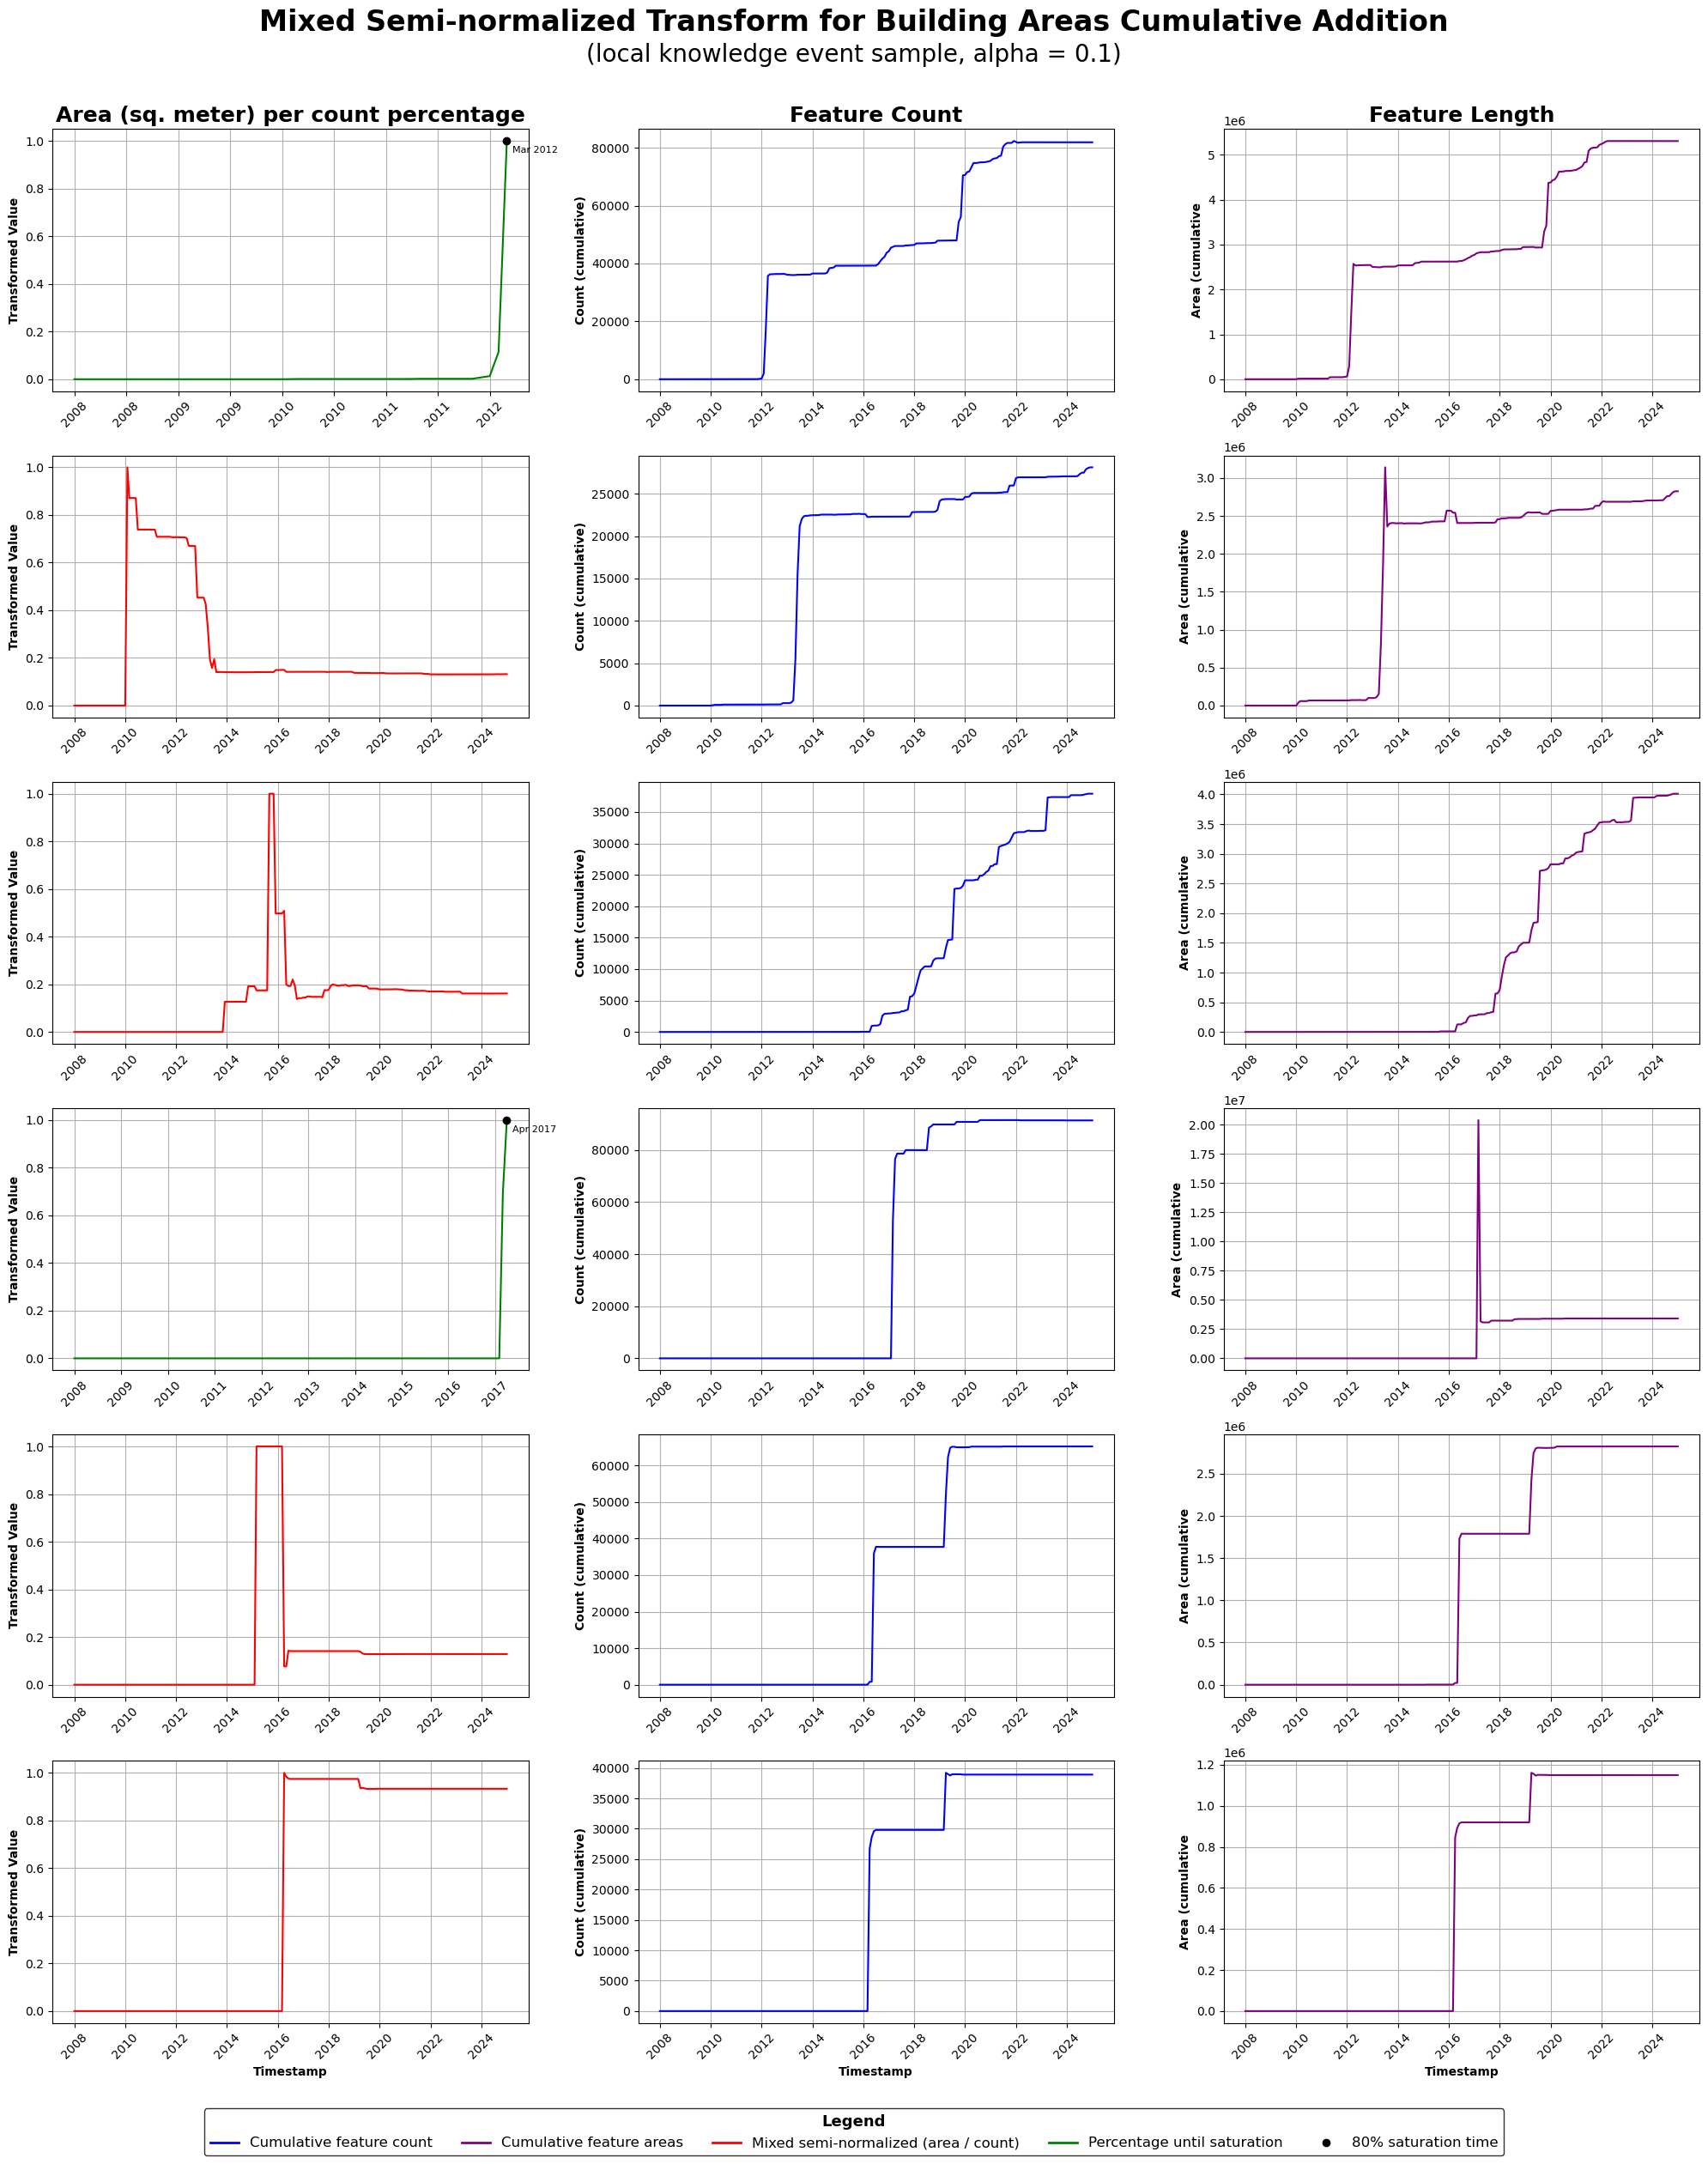

In [147]:
# Defining dataframes and subplot titles
fig, axes = plt.subplots(nrows=6, ncols=3, figsize=(20, 24))
column_titles = ['Area (sq. meter) per count percentage', 'Feature Count', 'Feature Length'] # Column titles

for i, df in enumerate(bldgs_test_samp):
    for j in range(3):
        ax = axes[i, j]
        # Plot 1: saturation percentage
        if j == 0:
            # Saturated values:
            if 'percentage_until_saturation' in df.columns:
                sat = (df['percentage_until_saturation'] >= 0.99).idxmax()
                df_plt = df.iloc[:sat + 1]
                ax.plot(df_plt['timestamp'], df_plt['percentage_until_saturation'], linestyle='-', color='g', label='Percentage until saturation')

                # Adding saturation point
                saturation = df[df['percentage_until_saturation'] >= 0.8].iloc[0]
                ax.scatter(saturation['timestamp'], saturation['percentage_until_saturation'], color='black', zorder=5, label='80% saturation')
                ax.annotate(pd.to_datetime(saturation['timestamp']).strftime('%b %Y'), xy=(saturation['timestamp'], saturation['percentage_until_saturation']),
                            xytext=(5, -10), textcoords='offset points', fontsize=8, color='black')

            # Un-saturated values:      
            else:
                ax.plot(df['timestamp'], df['normalized_cum_per'], linestyle='-', color='r', label='Mixed semi-normalized (area / count)')
            ax.set_ylabel('Transformed Value', weight='bold')
            if i == 5:
                # Only bottom of each column
                ax.set_xlabel('Timestamp', weight='bold')
            ax.tick_params(axis='x', rotation=45)
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
            ax.grid(True)

        # Plot 2: feature counts
        elif j == 1:
            ax.plot(df['timestamp'], df['count'], linestyle='-', color='b', label='Cumulative feature count')
            ax.set_ylabel('Count (cumulative)', weight='bold')
            if i == 5:
                # Only bottom of each column
                ax.set_xlabel('Timestamp', weight='bold')
            ax.tick_params(axis='x', rotation=45)
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
            ax.grid(True)

        # Plot 3: feature lengths
        elif j == 2:
            ax.plot(df['timestamp'], df['size'], linestyle='-', color='purple', label='Cumulative feature lengths')
            ax.set_ylabel('Area (cumulative', weight='bold')
            if i == 5:
                # Only bottom of each column
                ax.set_xlabel('Timestamp', weight='bold')
            ax.tick_params(axis='x', rotation=45)
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
            ax.grid(True)
        
        # Setting titles per each column
        if i == 0:
            axes[0, j].set_title(column_titles[j], fontsize=18, fontweight = 'bold')

# Setting legend
legend_elements = [
    Line2D([0], [0], color='b', lw=2, label='Cumulative feature count'),
    Line2D([0], [0], color='purple', lw=2, label='Cumulative feature areas'), 
    Line2D([0], [0], color='r', lw=2, label='Mixed semi-normalized (area / count)'),
    Line2D([0], [0], color='g', lw=2, label='Percentage until saturation'),
    Line2D([0], [0], marker='o', color='black', linestyle='', label='80% saturation time')
]

legend = fig.legend(
    handles=legend_elements,
    loc='upper center',
    ncol=5,
    bbox_to_anchor=(0.5, -0.005),
    fontsize=12,
    frameon=True,
    title='Legend',
    title_fontsize=13
)
#legend = legend_ax.legend(handles=legend_elements, loc='center', frameon=True, title='Legend')
legend.get_frame().set_edgecolor('black')
legend.get_title().set_fontweight('bold')

# Title
fig.text(0.5, 1, 'Mixed Semi-normalized Transform for Building Areas Cumulative Addition',
         fontsize=24, fontweight='bold', ha='center')
fig.text(0.5, 0.985, '(local knowledge event sample, alpha = 0.1)',
         fontsize=20, fontweight='normal', ha='center')

# Showing plots
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

##### Log scaled:

c:\Users\eliya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\eliya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


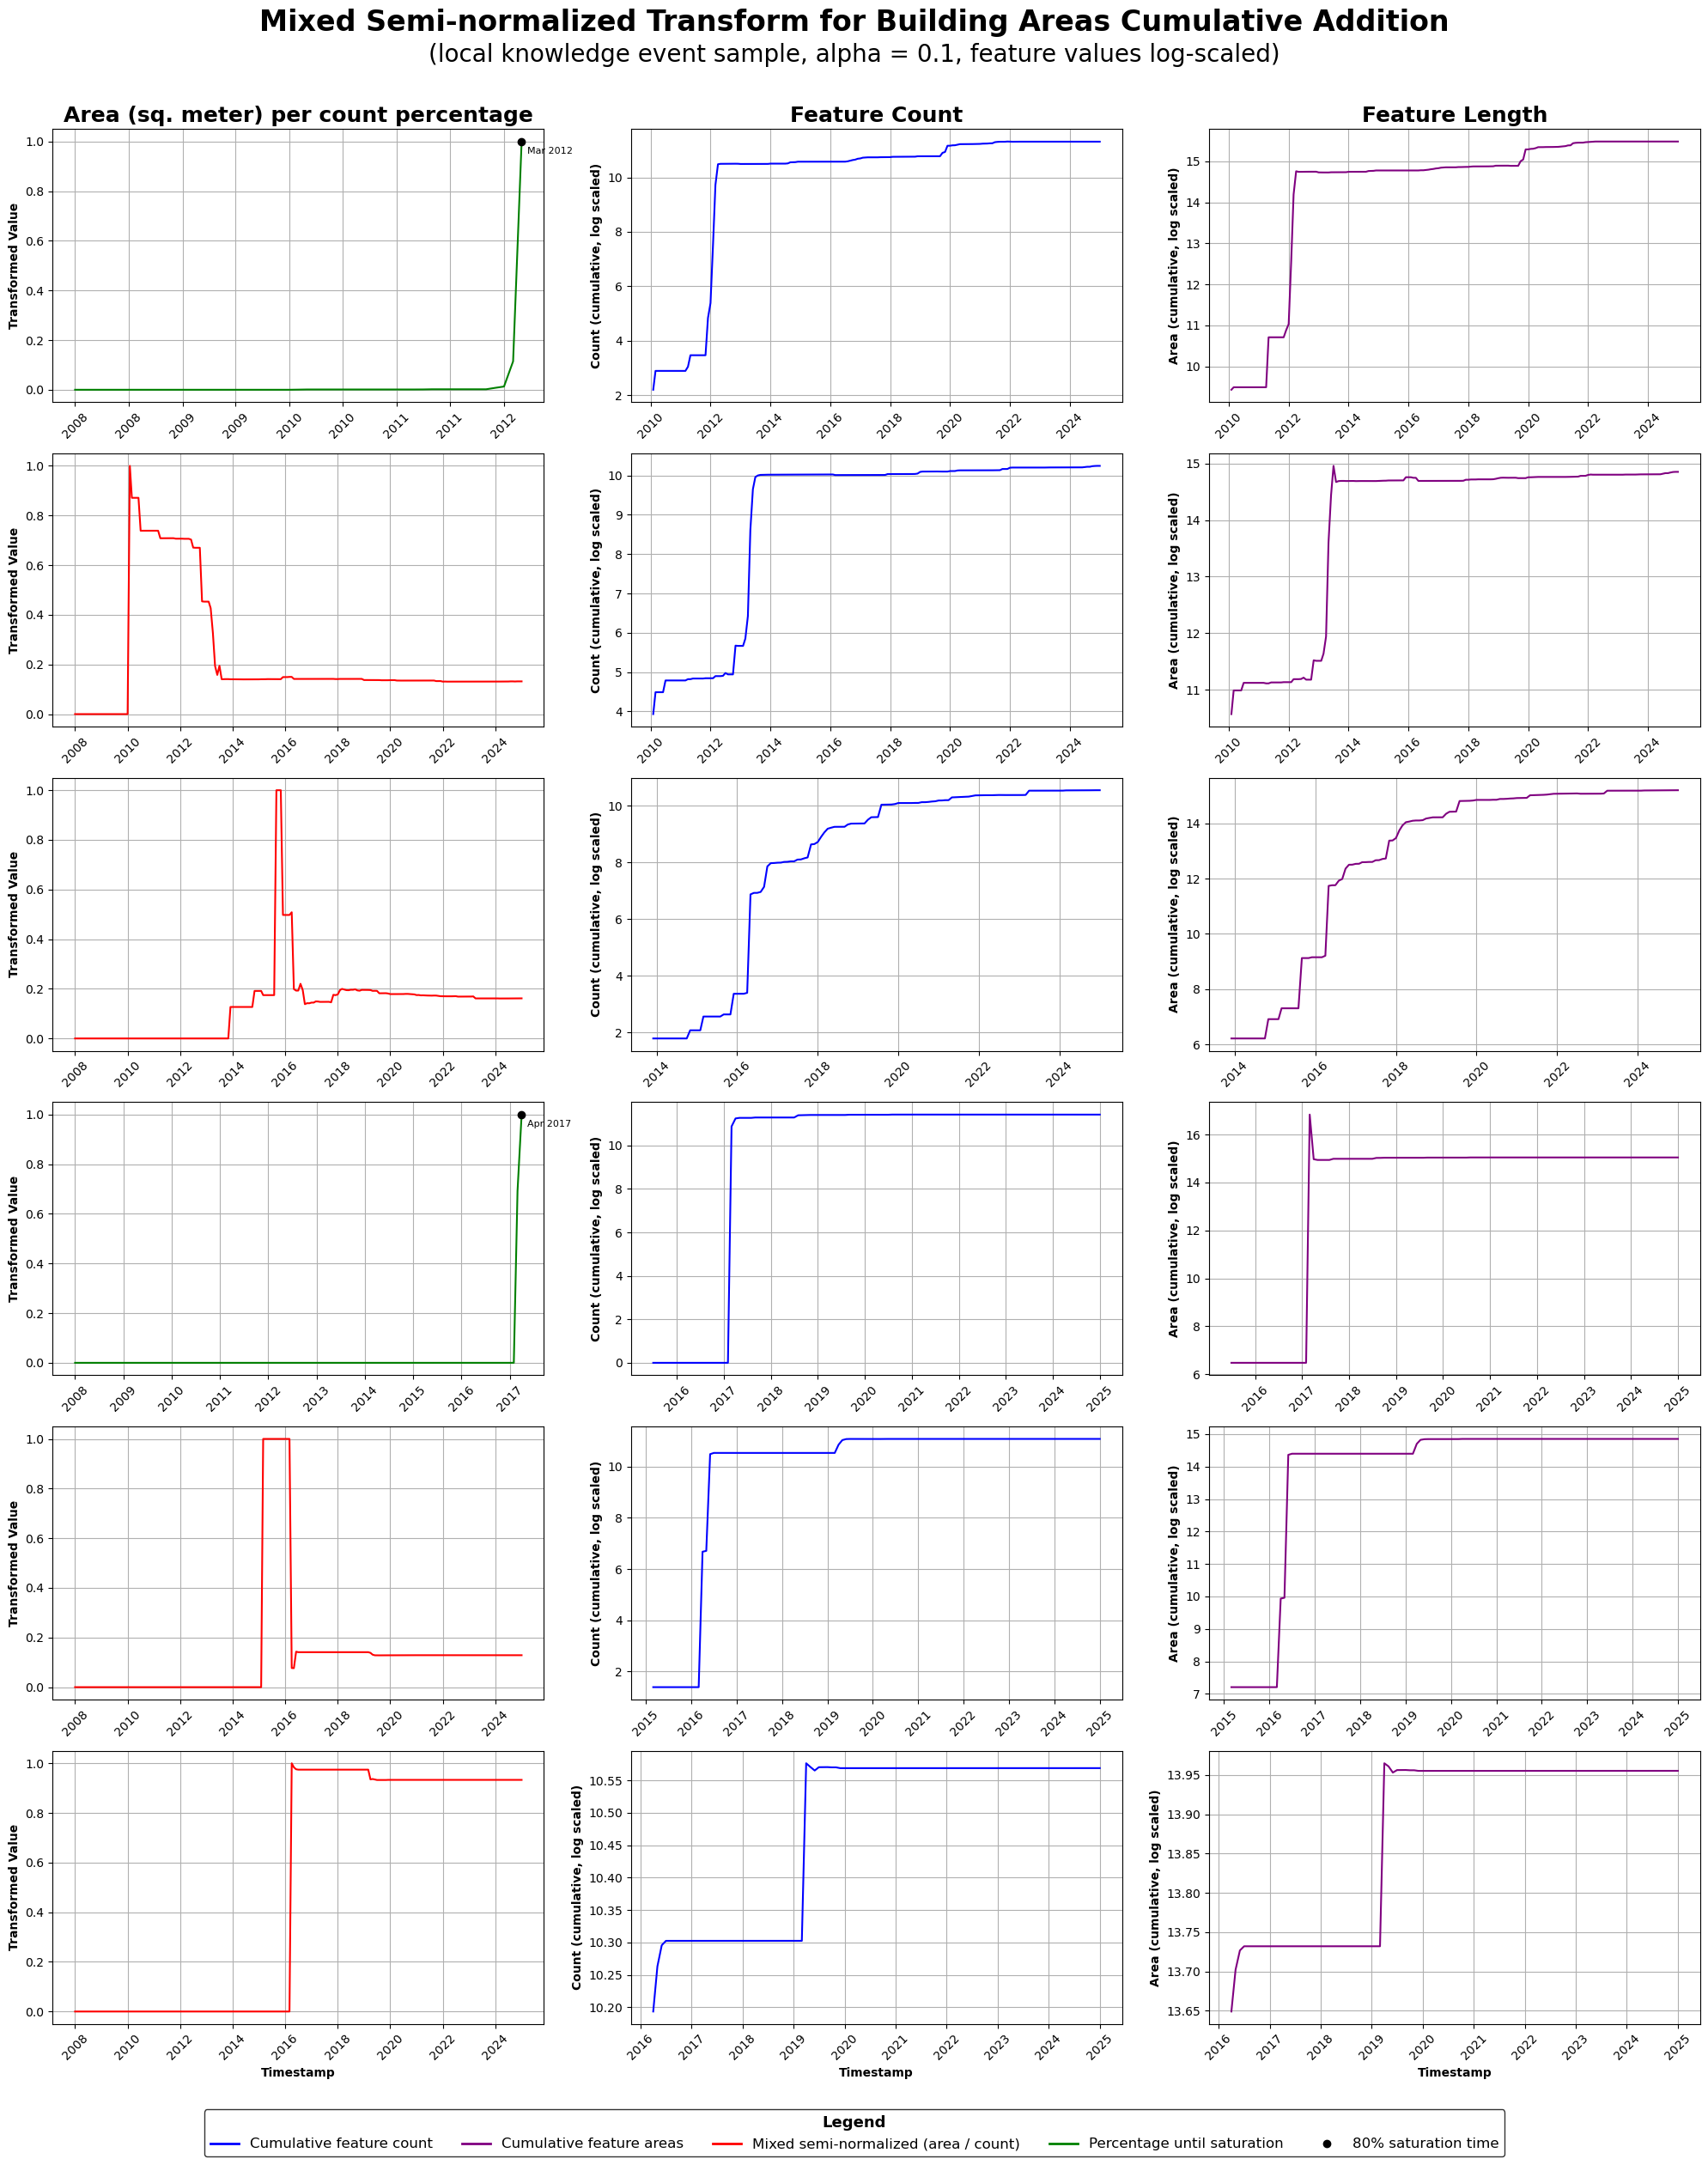

In [148]:
# Defining dataframes and subplot titles
fig, axes = plt.subplots(nrows=6, ncols=3, figsize=(20, 24))
column_titles = ['Area (sq. meter) per count percentage', 'Feature Count', 'Feature Length'] # Column titles

for i, df in enumerate(bldgs_test_samp):
    for j in range(3):
        ax = axes[i, j]
        # Plot 1: saturation percentage
        if j == 0:
            # Saturated values:
            if 'percentage_until_saturation' in df.columns:
                sat = (df['percentage_until_saturation'] >= 0.99).idxmax()
                df_plt = df.iloc[:sat + 1]
                ax.plot(df_plt['timestamp'], df_plt['percentage_until_saturation'], linestyle='-', color='g', label='Percentage until saturation')

                # Adding saturation point
                saturation = df[df['percentage_until_saturation'] >= 0.8].iloc[0]
                ax.scatter(saturation['timestamp'], saturation['percentage_until_saturation'], color='black', zorder=5, label='80% saturation')
                ax.annotate(pd.to_datetime(saturation['timestamp']).strftime('%b %Y'), xy=(saturation['timestamp'], saturation['percentage_until_saturation']),
                            xytext=(5, -10), textcoords='offset points', fontsize=8, color='black')

            # Un-saturated values:      
            else:
                ax.plot(df['timestamp'], df['normalized_cum_per'], linestyle='-', color='r', label='Mixed semi-normalized (area / count)')
            ax.set_ylabel('Transformed Value', weight='bold')
            if i == 5:
                # Only bottom of each column
                ax.set_xlabel('Timestamp', weight='bold')
            ax.tick_params(axis='x', rotation=45)
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
            ax.grid(True)

        # Plot 2: feature counts
        elif j == 1:
            ax.plot(df['timestamp'], np.log(df['count']), linestyle='-', color='b', label='Cumulative feature count')
            ax.set_ylabel('Count (cumulative, log scaled)', weight='bold')
            if i == 5:
                # Only bottom of each column
                ax.set_xlabel('Timestamp', weight='bold')
            ax.tick_params(axis='x', rotation=45)
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
            ax.grid(True)

        # Plot 3: feature lengths
        elif j == 2:
            ax.plot(df['timestamp'], np.log(df['size']), linestyle='-', color='purple', label='Cumulative feature lengths')
            ax.set_ylabel('Area (cumulative, log scaled)', weight='bold')
            if i == 5:
                # Only bottom of each column
                ax.set_xlabel('Timestamp', weight='bold')
            ax.tick_params(axis='x', rotation=45)
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
            ax.grid(True)
        
        # Setting titles per each column
        if i == 0:
            axes[0, j].set_title(column_titles[j], fontsize=18, fontweight = 'bold')

# Setting legend
legend_elements = [
    Line2D([0], [0], color='b', lw=2, label='Cumulative feature count'),
    Line2D([0], [0], color='purple', lw=2, label='Cumulative feature areas'), 
    Line2D([0], [0], color='r', lw=2, label='Mixed semi-normalized (area / count)'),
    Line2D([0], [0], color='g', lw=2, label='Percentage until saturation'),
    Line2D([0], [0], marker='o', color='black', linestyle='', label='80% saturation time')
]

legend = fig.legend(
    handles=legend_elements,
    loc='upper center',
    ncol=5,
    bbox_to_anchor=(0.5, -0.005),
    fontsize=12,
    frameon=True,
    title='Legend',
    title_fontsize=13
)
#legend = legend_ax.legend(handles=legend_elements, loc='center', frameon=True, title='Legend')
legend.get_frame().set_edgecolor('black')
legend.get_title().set_fontweight('bold')

# Title
fig.text(0.5, 1, 'Mixed Semi-normalized Transform for Building Areas Cumulative Addition',
         fontsize=24, fontweight='bold', ha='center')
fig.text(0.5, 0.985, '(local knowledge event sample, alpha = 0.1, feature values log-scaled)',
         fontsize=20, fontweight='normal', ha='center')

# Showing plots
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

#### Test entire sample

In [7]:
# Generate dataframes
roads_test = pd.concat(roads_test, ignore_index=True)
bldgs_test = pd.concat(bldgs_test, ignore_index=True)

In [8]:
# Fixing deleted column values for roads
roads_test['event_type'] = roads_test.groupby('idx')['event_type'].transform(lambda x: x.fillna(x.mode().iloc[0]))
roads_test['event_percentage'] = roads_test.groupby('idx')['event_percentage'].transform(lambda x: x.fillna(x.mode().iloc[0]))

# Fixing deleted column values for buildings
bldgs_test['event_type'] = bldgs_test.groupby('idx')['event_type'].transform(lambda x: x.fillna(x.mode().iloc[0]))
bldgs_test['event_percentage'] = bldgs_test.groupby('idx')['event_percentage'].transform(lambda x: x.fillna(x.mode().iloc[0]))

In [9]:
# Filtering only saturation and current rows or last 2 rows for unsaturated indices
roads_test_threshold = roads_test[
    (roads_test['percentage_until_saturation'] >= 1) | (roads_test['percentage_until_saturation'].isna())
].groupby('idx').tail(2)
    
bldgs_test_threshold = bldgs_test[
    (bldgs_test['percentage_until_saturation'] >= 1) | (bldgs_test['percentage_until_saturation'].isna())
].groupby('idx').tail(2)

In [11]:
# Uploading sample dataframe
events_sample = pd.read_csv(r"C:\Users\eliya\Documents\עבודה\עוזר מחקר\4. פרויקטים\1. quality measures\1. Feature Completeness\1) Data\2) Events export\events_sample_df.csv")

In [12]:
# Applying test results for each row in original sub-sample
results = events_sample[['event_type', 'event_percentage', 'bbox']].copy() # Clean DF

# Mapping road completeness values
road_completeness_map = roads_test_threshold.groupby('idx').tail(1).set_index('idx')['percentage_until_saturation'].notna().astype(int) # Reindexing and mapping boolean test check
results['road_completeness'] = results.index.map(road_completeness_map).fillna(0).astype(int) # Mapping each index to correct test result

# Mapping building completeness values
bldg_completeness_map = bldgs_test_threshold.groupby('idx').tail(1).set_index('idx')['percentage_until_saturation'].notna().astype(int) # Reindexing and mapping boolean test check
results['building_completeness'] = results.index.map(bldg_completeness_map).fillna(0).astype(int) # Mapping each index to correct test result

In [13]:
results.head(n=20)

,event_type,event_percentage,bbox,road_completeness,building_completeness
0,local_knowledge,63.997417,"-72.7734375,18.984375,-72.421875,19.16015625",1,1
1,local_knowledge,67.598822,"-72.421875,19.6875,-71.71875,20.0390625",0,0
2,local_knowledge,68.649403,"32.34375,-25.83984375,32.6953125,-25.6640625",1,0
3,local_knowledge,66.094857,"27.421875,-16.5234375,28.125,-16.171875",1,1
4,local_knowledge,66.532091,"34.453125,-19.6875,35.15625,-19.3359375",1,0
5,local_knowledge,64.310453,"33.75,-18.984375,34.453125,-18.6328125",1,0
6,local_knowledge,71.531864,"30.234375,-1.7578125,30.9375,-1.40625",1,1
7,local_knowledge,83.867608,"30.05859375,-1.40625,30.234375,-1.318359375",1,0
8,local_knowledge,66.725632,"29.8828125,-1.23046875,30.234375,-1.0546875",1,0
9,local_knowledge,71.024336,"39.19921875,-6.85546875,39.287109375,-6.811523...",0,1


In [ ]:
# Save results to csv
results.to_csv(r'C:\Users\eliya\Documents\עבודה\עוזר מחקר\4. פרויקטים\1. quality measures\1. Feature Completeness\1) Data\2) Events export\tests\event_sample_results_alpha=0_1.csv', index=False)

##### Measuring success

In [160]:
complete_road = sum(results['road_completeness'])
complete_bld = sum(results['building_completeness'])

In [161]:
print('Road Completeness:')
print(f'   n = {complete_road}\n   percentage = {round(complete_road / 446, 3)}')
print('\nBuilding Completeness:')
print(f'   n = {complete_bld}\n   percentage = {round(complete_bld / 446, 3)}')

Road Completeness:
   n = 315
   percentage = 0.706

Building Completeness:
   n = 208
   percentage = 0.466
